# Build Model Random Forest

Notebook ini membangun model final Random Forest dari hyperparameter terbaik hasil optimasi ABC dan PSO. Kedua model dilatih ulang pada seluruh data berstatus Critical, kemudian model utama dipilih berdasarkan CV MSE dari tahap optimasi.

Alur: konfigurasi → validasi artefak optimizer → persiapan data → training final → perbandingan → penyimpanan → verifikasi model.


## 1. Import library


In [1]:
import json
import platform
import re
from datetime import datetime, timezone
from importlib.metadata import version
from pathlib import Path
from typing import Any

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


## 2. Konfigurasi build

Konfigurasi awal menggunakan hasil optimasi ABC dan PSO untuk dataset PT Amanah. Path dan status training dapat diubah untuk dataset lain.


In [2]:
def find_root() -> Path:
    """Menemukan root proyek dari lokasi kerja notebook."""
    current = Path.cwd().resolve()
    for path in (current, *current.parents):
        if (path / "datas").is_dir() and (path / "newcode").is_dir():
            return path
    raise FileNotFoundError(
        "Root proyek dengan folder datas/ dan newcode/ tidak ditemukan"
    )


ROOT = find_root()

FEATURES = [
    "Exhaust Gas Temperature LF (Left Front)",
    "Exhaust Gas Temperature LR (Left Rear)",
    "Exhaust Gas Temperature RF (Right Front)",
    "Exhaust Gas Temperature RR (Right Rear)",
    "Blowby Pressure (Kpa)",
    "Boost Pressure (Kpa)",
    "Engine Oil Temp (°C)",
    "Coolant Temp (°C)",
]

cfg: dict[str, Any] = {
    "data": "datas/vehicle-health-gabungan.xlsx",
    "sheet": "Sheet1",
    "output": "newcode/models",
    "run_name": "data_gabungan",
    "features": FEATURES,
    "sources": {
        "abc": "newcode/artifacts/abc_rf_gabungan/metrics.json",
        "pso": "newcode/artifacts/pso_rf_gabungan/metrics.json",
    },
    "target": {
        "column": "sisa jam",
        "lifetime_column": "Unit Lifetime (Hour)",
        "status_column": "Status",
        "train_status": ["critical"],
        "break_status": "break",
        "failure_hour": None,
        "max_rul": 2550,
    },
    "seed": 42,
    "n_jobs": -1,
}

cfg


{'data': 'datas/vehicle-health-gabungan.xlsx',
 'sheet': 'Sheet1',
 'output': 'newcode/models',
 'run_name': 'data_gabungan',
 'features': ['Exhaust Gas Temperature LF (Left Front)',
  'Exhaust Gas Temperature LR (Left Rear)',
  'Exhaust Gas Temperature RF (Right Front)',
  'Exhaust Gas Temperature RR (Right Rear)',
  'Blowby Pressure (Kpa)',
  'Boost Pressure (Kpa)',
  'Engine Oil Temp (°C)',
  'Coolant Temp (°C)'],
 'sources': {'abc': 'newcode/artifacts/abc_rf_gabungan/metrics.json',
  'pso': 'newcode/artifacts/pso_rf_gabungan/metrics.json'},
 'target': {'column': 'sisa jam',
  'lifetime_column': 'Unit Lifetime (Hour)',
  'status_column': 'Status',
  'train_status': ['critical'],
  'break_status': 'break',
  'failure_hour': None,
  'max_rul': 2550},
 'seed': 42,
 'n_jobs': -1}

## 3. Fungsi path, kolom, dan pemuatan data


In [3]:
def abs_path(val: str | Path) -> Path:
    """Mengubah path relatif menjadi path dari root proyek."""
    path = Path(val)
    return path if path.is_absolute() else ROOT / path


def norm_col(val: str) -> str:
    """Menormalkan nama kolom dan variasi satuan temperatur."""
    text = re.sub(r"\s+", " ", str(val).strip()).casefold()
    return text.replace(" (°c)", "")


def col_map(df: pd.DataFrame) -> dict[str, str]:
    """Membuat peta nama kolom ternormalisasi ke nama aktual."""
    out: dict[str, str] = {}
    for col in df.columns:
        key = norm_col(col)
        if key in out:
            raise ValueError(
                f"Nama kolom menjadi ambigu setelah normalisasi: {col}"
            )
        out[key] = str(col)
    return out


def find_col(
    cols: dict[str, str],
    name: str,
    required: bool = True,
) -> str | None:
    """Mencari kolom dengan toleransi kapitalisasi dan satuan °C."""
    col = cols.get(norm_col(name))
    if col is None and required:
        raise ValueError(f"Kolom wajib tidak ditemukan: {name}")
    return col


def load_table(path: Path, sheet: str | int = 0) -> pd.DataFrame:
    """Memuat dataset Excel atau CSV."""
    if not path.exists():
        raise FileNotFoundError(f"Dataset tidak ditemukan: {path}")
    if path.suffix.casefold() in {".xlsx", ".xls"}:
        return pd.read_excel(path, sheet_name=sheet)
    if path.suffix.casefold() == ".csv":
        return pd.read_csv(path)
    raise ValueError("Format dataset harus .xlsx, .xls, atau .csv")


## 4. Fungsi persiapan data

Target yang sudah tersedia akan digunakan langsung. Jika target tidak tersedia, RUL dibentuk dari failure_hour atau lifetime pada satu baris berstatus Break.


In [4]:
def prep_data(
    raw: pd.DataFrame,
    cfg: dict[str, Any],
) -> tuple[pd.DataFrame, dict[str, Any]]:
    """Membersihkan dataset dan membentuk target training."""
    target = cfg["target"]
    cols = col_map(raw)
    feat_src = [find_col(cols, name) for name in cfg["features"]]
    life_src = find_col(cols, target["lifetime_column"])
    status_src = find_col(cols, target["status_column"])
    target_src = find_col(cols, target["column"], required=False)

    data = pd.DataFrame(index=raw.index)
    for name, source in zip(cfg["features"], feat_src, strict=True):
        data[name] = pd.to_numeric(raw[source], errors="coerce")
    data["_lifetime"] = pd.to_numeric(raw[life_src], errors="coerce")
    data["_status"] = (
        raw[status_src].astype("string").str.strip().str.casefold()
    )

    if target_src is not None:
        data["_target"] = pd.to_numeric(raw[target_src], errors="coerce")

    need = [*cfg["features"], "_lifetime", "_status"]
    before = len(data)
    data = data.dropna(subset=need).copy()
    dropped = before - len(data)
    data = data.sort_values("_lifetime", kind="stable").reset_index(drop=True)

    fail_hour = target.get("failure_hour")
    target_mode = "existing"
    if target_src is not None:
        data = data.dropna(subset=["_target"]).copy()
    else:
        target_mode = "derived"
        if fail_hour is None:
            break_status = str(target["break_status"]).strip().casefold()
            break_hours = data.loc[
                data["_status"] == break_status,
                "_lifetime",
            ].unique()
            if len(break_hours) != 1:
                raise ValueError(
                    "Target tidak tersedia dan failure hour tidak dapat "
                    "ditentukan secara tunggal."
                )
            fail_hour = float(break_hours[0])

        data["_target"] = float(fail_hour) - data["_lifetime"]
        data["_target"] = data["_target"].clip(lower=0)
        max_rul = target.get("max_rul")
        if max_rul is not None:
            data["_target"] = data["_target"].clip(upper=float(max_rul))

    statuses = [
        str(val).strip().casefold()
        for val in target.get("train_status", [])
    ]
    if statuses:
        data = data[data["_status"].isin(statuses)].copy()
    if data.empty:
        raise ValueError("Tidak ada data tersisa untuk training final")

    data = data.reset_index(drop=True)
    meta = {
        "raw_rows": int(len(raw)),
        "train_rows": int(len(data)),
        "dropped_invalid_rows": int(dropped),
        "target_mode": target_mode,
        "failure_hour": None if fail_hour is None else float(fail_hour),
        "target_min": float(data["_target"].min()),
        "target_max": float(data["_target"].max()),
        "lifetime_min": float(data["_lifetime"].min()),
        "lifetime_max": float(data["_lifetime"].max()),
        "train_status": statuses,
    }
    return data, meta


## 5. Memuat dan memvalidasi hasil optimizer

Model utama dipilih berdasarkan CV MSE terkecil. Metrik test tetap ditampilkan sebagai informasi, tetapi tidak digunakan untuk pemilihan.


In [5]:
PARAM_KEYS = {
    "n_estimators",
    "max_depth",
    "min_samples_split",
    "min_samples_leaf",
    "max_features",
}


def load_run(path: Path, name: str) -> dict[str, Any]:
    """Memuat dan memvalidasi satu hasil optimasi."""
    if not path.exists():
        raise FileNotFoundError(
            f"Artefak {name.upper()} tidak ditemukan: {path}. "
            "Jalankan notebook optimasi terlebih dahulu."
        )
    run = json.loads(path.read_text(encoding="utf-8"))
    missing = PARAM_KEYS - set(run.get("best_params", {}))
    if missing:
        raise ValueError(
            f"Parameter {name.upper()} tidak lengkap: {sorted(missing)}"
        )
    if "cv_mse" not in run or "config" not in run:
        raise ValueError(f"Metadata optimizer tidak lengkap: {name}")
    return run


runs = {
    name: load_run(abs_path(path), name)
    for name, path in cfg["sources"].items()
}

base_name = next(iter(runs))
base_cfg = runs[base_name]["config"]
checks = ["data", "features", "target", "split", "seed"]
for name, run in runs.items():
    other = run["config"]
    mismatch = [key for key in checks if other.get(key) != base_cfg.get(key)]
    if mismatch:
        raise ValueError(
            f"Kontrak eksperimen {name.upper()} berbeda pada: {mismatch}"
        )

build_contract = {
    "data": cfg["data"],
    "features": cfg["features"],
    "target": cfg["target"],
    "seed": cfg["seed"],
}
source_contract = {
    "data": base_cfg["data"],
    "features": base_cfg["features"],
    "target": base_cfg["target"],
    "seed": base_cfg["seed"],
}
if build_contract != source_contract:
    raise ValueError(
        "Kontrak build berbeda dari kontrak yang digunakan saat optimasi"
    )

best_name = min(runs, key=lambda name: float(runs[name]["cv_mse"]))
print(f"Optimizer terpilih berdasarkan CV MSE: {best_name.upper()}")


Optimizer terpilih berdasarkan CV MSE: PSO


In [6]:
opt_rows = []
for name, run in runs.items():
    test = run["test_metrics"]
    opt_rows.append(
        {
            "optimizer": name.upper(),
            "cv_mse": run["cv_mse"],
            "cv_rmse": run["cv_rmse"],
            "test_mse": test["mse"],
            "test_rmse": test["rmse"],
            "test_mae": test["mae"],
            "test_r2": test["r2"],
        }
    )

opt_df = pd.DataFrame(opt_rows).sort_values("cv_mse").reset_index(drop=True)
display(opt_df)


,optimizer,cv_mse,cv_rmse,test_mse,test_rmse,test_mae,test_r2
0,PSO,26189.710892,161.832354,17025.217429,130.480717,65.646114,0.980680
1,ABC,26342.255290,162.302974,15856.091429,125.920973,61.916534,0.982006


## 6. Menyiapkan seluruh data Critical

Tidak ada holdout baru pada tahap build. Evaluasi generalisasi sudah dilakukan di notebook optimasi; build model menggunakan seluruh data yang sesuai kontrak untuk menghasilkan model final.


In [7]:
data_path = abs_path(cfg["data"])
raw = load_table(data_path, cfg["sheet"])
data, data_meta = prep_data(raw, cfg)

features = list(cfg["features"])
x = data[features]
y = data["_target"]

print(json.dumps(data_meta, ensure_ascii=False, indent=2))
display(data.head())


{
  "raw_rows": 3168,
  "train_rows": 1296,
  "dropped_invalid_rows": 0,
  "target_mode": "derived",
  "failure_hour": 78637.0,
  "target_min": 1.0,
  "target_max": 2550.0,
  "lifetime_min": 49249.12,
  "lifetime_max": 78636.0,
  "train_status": [
    "critical"
  ]
}


,Exhaust Gas Temperature LF (Left Front),Exhaust Gas Temperature LR (Left Rear),Exhaust Gas Temperature RF (Right Front),Exhaust Gas Temperature RR (Right Rear),Blowby Pressure (Kpa),Boost Pressure (Kpa),Engine Oil Temp (°C),Coolant Temp (°C),_lifetime,_status,_target
0,623.0,642.0,627.0,618.0,14.3,121.0,96.0,83.0,49249.120000,critical,2550.0
1,629.0,651.0,637.0,626.0,15.1,121.0,96.0,82.0,49269.170000,critical,2550.0
2,619.0,648.0,632.0,624.0,16.4,119.0,96.0,82.0,49289.240000,critical,2550.0
3,625.0,652.0,637.0,626.0,14.6,121.0,96.0,81.0,49309.233333,critical,2550.0
4,618.0,642.0,629.0,620.0,14.9,119.0,96.0,82.0,49329.283333,critical,2550.0


## 7. Melatih model final ABC dan PSO


In [8]:
def metric_values(
    actual: pd.Series,
    pred: np.ndarray,
) -> dict[str, float]:
    """Menghitung metrik training untuk diagnosis, bukan evaluasi final."""
    mse = float(mean_squared_error(actual, pred))
    return {
        "mse": mse,
        "rmse": float(np.sqrt(mse)),
        "mae": float(mean_absolute_error(actual, pred)),
        "r2": float(r2_score(actual, pred)),
    }


models: dict[str, RandomForestRegressor] = {}
preds: dict[str, np.ndarray] = {}
train_metrics: dict[str, dict[str, float]] = {}

for name, run in runs.items():
    params = run["best_params"]
    model = RandomForestRegressor(
        **params,
        random_state=int(cfg["seed"]),
        n_jobs=int(cfg["n_jobs"]),
    )
    model.fit(x, y)
    pred = model.predict(x)

    models[name] = model
    preds[name] = pred
    train_metrics[name] = metric_values(y, pred)
    print(f"Model final {name.upper()} berhasil dilatih.")


Model final ABC berhasil dilatih.
Model final PSO berhasil dilatih.


In [9]:
build_rows = []
for name in runs:
    build_rows.append(
        {
            "optimizer": name.upper(),
            "selected": name == best_name,
            "cv_mse": runs[name]["cv_mse"],
            "test_rmse": runs[name]["test_metrics"]["rmse"],
            "test_mae": runs[name]["test_metrics"]["mae"],
            "test_r2": runs[name]["test_metrics"]["r2"],
            "train_rmse_diagnostic": train_metrics[name]["rmse"],
        }
    )

build_df = pd.DataFrame(build_rows).sort_values("cv_mse").reset_index(drop=True)
display(build_df)


,optimizer,selected,cv_mse,test_rmse,test_mae,test_r2,train_rmse_diagnostic
0,PSO,True,26189.710892,130.480717,65.646114,0.980680,45.592325
1,ABC,False,26342.255290,125.920973,61.916534,0.982006,46.280479


## 8. Visualisasi prediksi model final

Metrik dan grafik pada seluruh data training hanya bersifat diagnostik. Nilai evaluasi generalisasi tetap berasal dari holdout pada notebook optimizer.


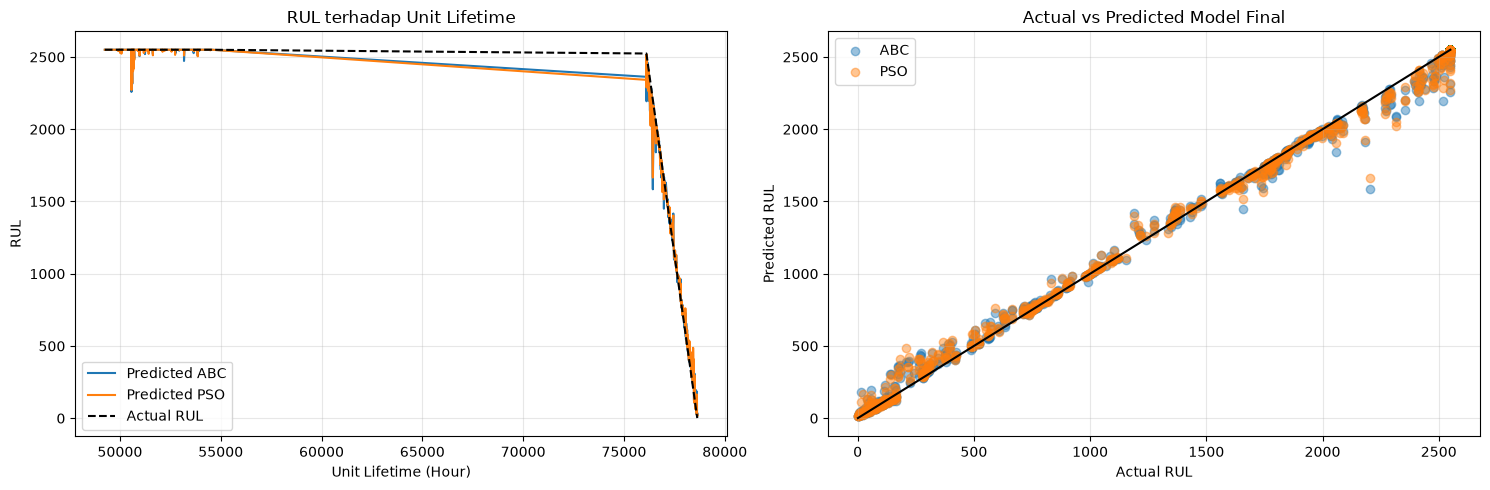

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for name, pred in preds.items():
    axes[0].plot(
        data["_lifetime"],
        pred,
        linewidth=1.5,
        label=f"Predicted {name.upper()}",
    )
axes[0].plot(
    data["_lifetime"],
    y,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label="Actual RUL",
)
axes[0].set(
    title="RUL terhadap Unit Lifetime",
    xlabel="Unit Lifetime (Hour)",
    ylabel="RUL",
)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

for name, pred in preds.items():
    axes[1].scatter(y, pred, alpha=0.45, label=name.upper())
low = float(min(y.min(), *(pred.min() for pred in preds.values())))
high = float(max(y.max(), *(pred.max() for pred in preds.values())))
axes[1].plot([low, high], [low, high], color="black", linewidth=1.5)
axes[1].set(
    title="Actual vs Predicted Model Final",
    xlabel="Actual RUL",
    ylabel="Predicted RUL",
)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 9. Menyimpan model dan metadata

Setiap bundle menyimpan model, urutan fitur, aturan target, optimizer, hyperparameter, serta metadata data. Alias random_forest_best.joblib menunjuk pada optimizer dengan CV MSE terkecil.


In [11]:
def json_ready(val: Any) -> Any:
    """Mengubah nilai NumPy dan Path agar dapat ditulis ke JSON."""
    if isinstance(val, dict):
        return {str(key): json_ready(item) for key, item in val.items()}
    if isinstance(val, (list, tuple)):
        return [json_ready(item) for item in val]
    if isinstance(val, Path):
        return str(val)
    if isinstance(val, np.generic):
        return val.item()
    return val


out = abs_path(cfg["output"]) / str(cfg["run_name"])
out.mkdir(parents=True, exist_ok=True)

bundles: dict[str, dict[str, Any]] = {}
for name, model in models.items():
    bundle = {
        "model": model,
        "optimizer": name,
        "features": features,
        "params": runs[name]["best_params"],
        "target": cfg["target"],
        "data_meta": data_meta,
        "seed": cfg["seed"],
    }
    bundles[name] = bundle
    joblib.dump(bundle, out / f"random_forest_{name}.joblib")

joblib.dump(
    bundles[best_name],
    out / "random_forest_best.joblib",
)

pred_df = data[["_lifetime", "_status", "_target"]].copy()
pred_df.columns = ["lifetime", "status", "actual_rul"]
for name, pred in preds.items():
    pred_df[f"predicted_rul_{name}"] = pred
pred_df.to_csv(out / "training_predictions.csv", index=False)

summary = {
    "built_at_utc": datetime.now(timezone.utc).isoformat(),
    "data": str(data_path),
    "data_meta": data_meta,
    "selection_metric": "cv_mse",
    "selected_optimizer": best_name,
    "optimizer_results": {
        name: {
            "source": str(abs_path(cfg["sources"][name])),
            "best_params": runs[name]["best_params"],
            "cv_mse": runs[name]["cv_mse"],
            "cv_rmse": runs[name]["cv_rmse"],
            "test_metrics": runs[name]["test_metrics"],
            "train_metrics_diagnostic": train_metrics[name],
        }
        for name in runs
    },
    "versions": {
        "python": platform.python_version(),
        "numpy": version("numpy"),
        "pandas": version("pandas"),
        "scikit_learn": version("scikit-learn"),
        "joblib": version("joblib"),
    },
}
(out / "build_summary.json").write_text(
    json.dumps(json_ready(summary), ensure_ascii=False, indent=2),
    encoding="utf-8",
)
fig.savefig(out / "model_comparison.png", dpi=160, bbox_inches="tight")

print(f"Model dan metadata disimpan di: {out}")
print(f"Model utama: {best_name.upper()}")


Model dan metadata disimpan di: /home/khai/work/cls/vehicle-health/newcode/models/data_gabungan
Model utama: PSO


## 10. Memuat ulang dan memverifikasi model

Verifikasi memastikan setiap file berisi optimizer yang benar dan memberikan prediksi identik dengan model sebelum disimpan.


In [12]:
sample = x.head(min(20, len(x)))
verify_rows = []

for name in runs:
    path = out / f"random_forest_{name}.joblib"
    loaded = joblib.load(path)
    before = models[name].predict(sample)
    after = loaded["model"].predict(sample)
    same = bool(np.allclose(before, after))
    verify_rows.append(
        {
            "file": path.name,
            "optimizer": loaded["optimizer"].upper(),
            "prediction_identical": same,
        }
    )
    if loaded["optimizer"] != name or not same:
        raise RuntimeError(f"Verifikasi model gagal: {name}")

best_bundle = joblib.load(out / "random_forest_best.joblib")
if best_bundle["optimizer"] != best_name:
    raise RuntimeError("Alias model terbaik tidak sesuai hasil seleksi")

verify_df = pd.DataFrame(verify_rows)
display(verify_df)
print("Seluruh model berhasil dimuat ulang dan diverifikasi.")


,file,optimizer,prediction_identical
0,random_forest_abc.joblib,ABC,True
1,random_forest_pso.joblib,PSO,True


Seluruh model berhasil dimuat ulang dan diverifikasi.
